In [2]:
library(readxl)
library(eRm)

In [3]:
data <- read_excel("data_dea.xlsx")

In [4]:
head(data)

S1,S2,S3,S4,S5,S6,S7,S8,S9,S10,S11,S12
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3,2,2,3,4,0,2,4,4,4,3
2,4,1,2,1,4,0,0,3,4,2,4
2,4,2,2,4,4,0,1,2,0,2,4
2,4,2,4,2,4,0,1,2,0,1,4
2,4,1,2,3,4,4,3,4,4,4,4
4,4,1,3,2,4,0,4,4,4,4,3


In [5]:
data_matrix <- as.matrix(data)
mode(data_matrix) <- "numeric"

In [6]:
data_matrix[is.na(data_matrix)] <- 0

In [7]:
head(data_matrix)

S1,S2,S3,S4,S5,S6,S7,S8,S9,S10,S11,S12
1,3,2,2,3,4,0,2,4,4,4,3
2,4,1,2,1,4,0,0,3,4,2,4
2,4,2,2,4,4,0,1,2,0,2,4
2,4,2,4,2,4,0,1,2,0,1,4
2,4,1,2,3,4,4,3,4,4,4,4
4,4,1,3,2,4,0,4,4,4,4,3


Data respons menggunakan skala 1-4. Analisis Rasch (PCM) menggunakan pergeseran (shift) ke skala 0-3 untuk pemenuhan asumsi komputasi paket eRm. Oleh karena itu, parameter ambang batas c1, c2, dan c3 pada output statistik merepresentasikan ambang batas untuk pencapaian skor 2, 3, dan 4 secara berturut-turut

In [12]:
head(data_matrix)

S1,S2,S3,S4,S5,S6,S7,S8,S9,S10,S11,S12
1,3,2,2,3,4,0,2,4,4,4,3
2,4,1,2,1,4,0,0,3,4,2,4
2,4,2,2,4,4,0,1,2,0,2,4
2,4,2,4,2,4,0,1,2,0,1,4
2,4,1,2,3,4,4,3,4,4,4,4
4,4,1,3,2,4,0,4,4,4,4,3


In [13]:
df_data <- as.data.frame(data_matrix)

# Membuat fungsi untuk merangkum distribusi per kolom
distribusi_soal <- lapply(df_data, function(x) table(factor(x, levels = 0:4)))

# Menampilkan hasil dalam bentuk tabel yang rapi
do.call(rbind, distribusi_soal)

,0,1,2,3,4
S1,8,8,11,50,25
S2,0,2,11,43,46
S3,1,38,35,16,12
S4,1,45,32,19,5
S5,0,35,23,30,14
S6,4,7,9,7,75
S7,48,2,19,13,20
S8,6,11,20,31,34
S9,4,4,26,27,41
S10,15,12,9,13,53


In [14]:
rasch_model_poli <- PCM(data_matrix)
summary(rasch_model_poli)

Warning message:
“
The following items have no 0-responses:
S2 S5
Responses are shifted such that lowest category is 0.”



Results of PCM estimation: 

Call:  PCM(X = data_matrix) 

Conditional log-likelihood: -1181.931 
Number of iterations: 54 
Number of parameters: 45 

Item (Category) Difficulty Parameters (eta): with 0.95 CI:
       Estimate Std. Error lower CI upper CI
S1.c2     0.427      0.471   -0.496    1.349
S1.c3    -0.511      0.416   -1.328    0.305
S1.c4     0.904      0.473   -0.024    1.831
S2.c1    -1.352      0.755   -2.831    0.127
S2.c2    -2.224      0.703   -3.603   -0.846
S2.c3    -1.646      0.704   -3.027   -0.266
S3.c1    -3.235      0.980   -5.156   -1.314
S3.c2    -2.611      0.954   -4.480   -0.741
S3.c3    -1.137      0.949   -2.998    0.723
S3.c4    -0.014      0.947   -1.870    1.841
S4.c1    -3.384      0.978   -5.301   -1.467
S4.c2    -2.475      0.955   -4.347   -0.604
S4.c3    -1.235      0.945   -3.087    0.616
S4.c4     0.963      1.004   -1.006    2.931
S5.c1     0.930      0.276    0.389    1.471
S5.c2     1.320      0.290    0.752    1.887
S5.c3     2.883      0.3

In [15]:
# LANGKAH 4: Estimasi Parameter Kemampuan Responden (Person Parameters)
# R menghitung skor kemampuan (latent trait/theta) untuk setiap siswa berdasarkan respons mereka.
person_param <- person.parameter(rasch_model_poli)
summary(person_param)


Estimation of Ability Parameters

Collapsed log-likelihood: -391.9473 
Number of iterations: 12 
Number of parameters: 28 

ML estimated ability parameters (without spline interpolated values): 
              Estimate Std. Err.       2.5 %     97.5 %
theta P1    0.64827588 0.2638876  0.13106568 1.16548608
theta P2    0.32401419 0.2480407 -0.16213659 0.81016498
theta P3    0.32401419 0.2480407 -0.16213659 0.81016498
theta P4    0.26284440 0.2467099 -0.22069802 0.74638682
theta P5    1.24178251 0.3309683  0.59309648 1.89046854
theta P6    1.04213918 0.3025629  0.44912681 1.63515156
theta P7    0.95388711 0.2918952  0.38178296 1.52599126
theta P8    0.71928441 0.2692146  0.19163358 1.24693524
theta P9    1.63832455 0.4029594  0.84853862 2.42811047
theta P10   0.44907423 0.2524780 -0.04577364 0.94392211
theta P11   0.38598999 0.2499623 -0.10392719 0.87590717
theta P12   0.44907423 0.2524780 -0.04577364 0.94392211
theta P13   1.13749257 0.3154098  0.51930077 1.75568437
theta P14   0.513582

In [16]:
# Memaksa R menggunakan fungsi itemfit khusus dari paket eRm
fit_butir <- eRm::itemfit(person_param)

# Tampilkan hasilnya
print(fit_butir)


Itemfit Statistics: 
      Chisq  df p-value Outfit MSQ Infit MSQ Outfit t Infit t Discrim
S1   83.349 101   0.899      0.817     0.848   -1.088  -1.043   0.495
S2  106.950 101   0.324      1.049     1.027    0.367   0.233   0.212
S3   91.338 101   0.744      0.895     0.929   -0.749  -0.541   0.402
S4  106.047 101   0.346      1.040     0.984    0.331  -0.086   0.289
S5  115.002 101   0.161      1.127     1.046    1.094   0.456   0.258
S6   78.244 101   0.955      0.767     0.872   -0.718  -0.708   0.461
S7  154.932 101   0.000      1.519     1.377    2.762   2.901   0.096
S8   80.632 101   0.933      0.791     0.851   -1.499  -1.161   0.532
S9   84.324 101   0.884      0.827     0.866   -1.155  -0.935   0.486
S10  74.406 101   0.978      0.729     0.856   -1.389  -1.172   0.527
S11  78.293 101   0.954      0.768     0.776   -1.975  -2.030   0.596
S12  68.497 101   0.995      0.672     0.771   -1.598  -1.714   0.570



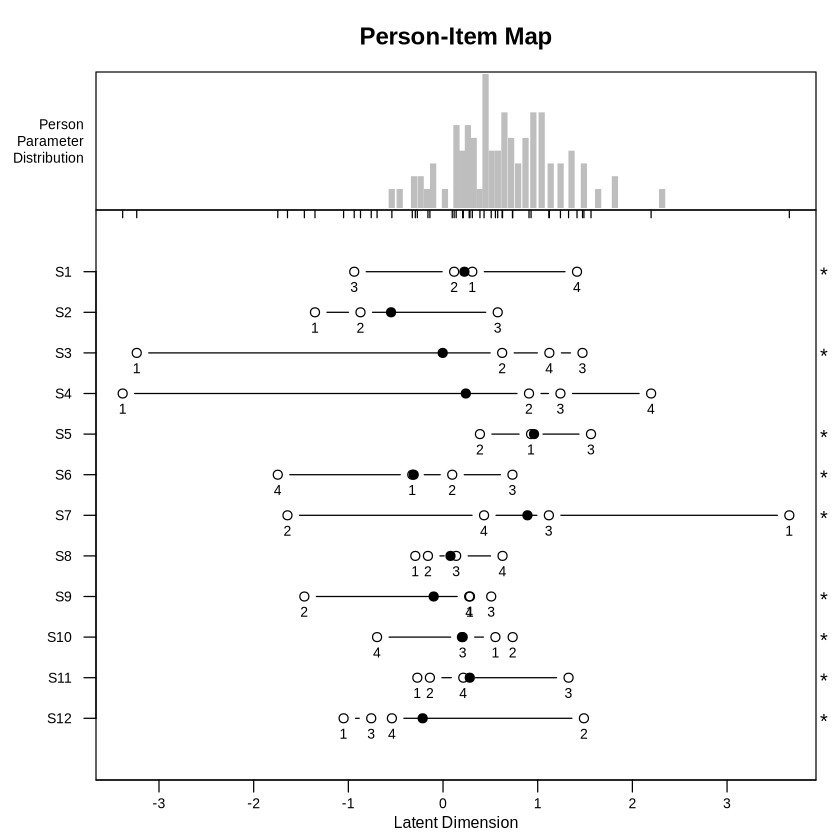

In [19]:
# LANGKAH 6: Visualisasi Person-Item Map (Wright Map)
# Menjajarkan kemampuan siswa dan tingkat kesulitan soal dalam satu grafik.
plotPImap(rasch_model_poli)

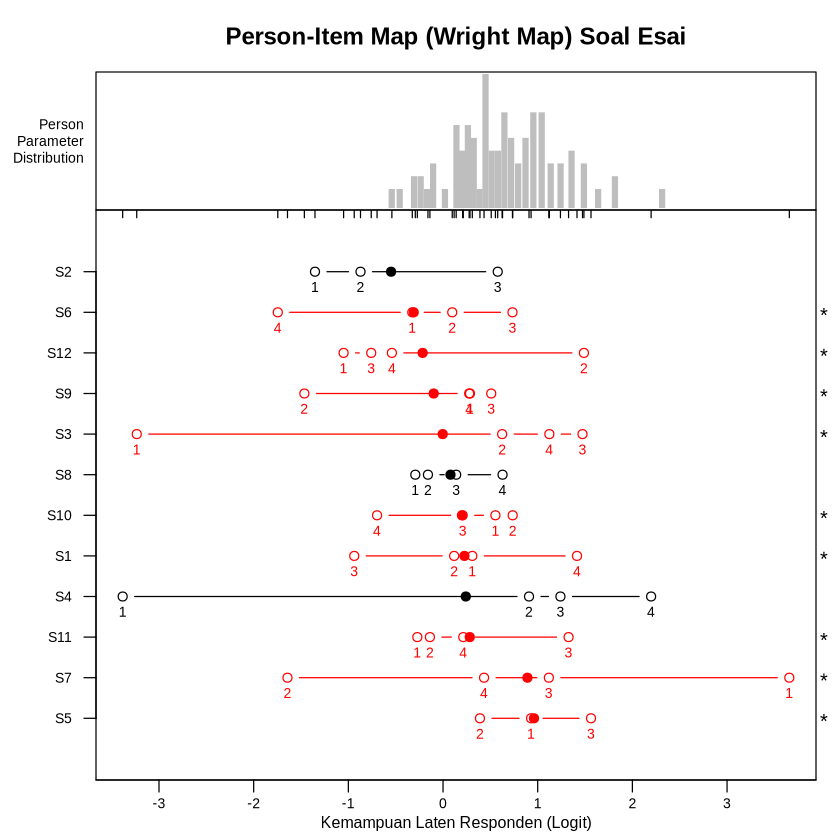

In [20]:
# Versi bersih dan aman yang didukung penuh oleh paket eRm
plotPImap(rasch_model_poli, 
          sorted = TRUE,          # Tetap mempertahankan urutan dari termudah ke tersulit
          main = "Person-Item Map (Wright Map) Soal Esai", 
          latdim = "Kemampuan Laten Responden (Logit)", 
          warn.ord = TRUE,         # Memberi penanda jika ada threshold yang disordered
          warn.ord.col = "red")    # Warna penanda untuk threshold yang bermasalah

Gambar 4.2 Person-Item Map (Wright Map) Kemampuan Pemecahan Masalah Siswa.
Catatan: Suffix .c1, .c2, dan .c3 pada label butir soal secara berturut-turut merepresentasikan ambang batas (threshold) kemampuan untuk mencapai Skor 2, Skor 3, dan Skor 4 pada rubrik penilaian asli.

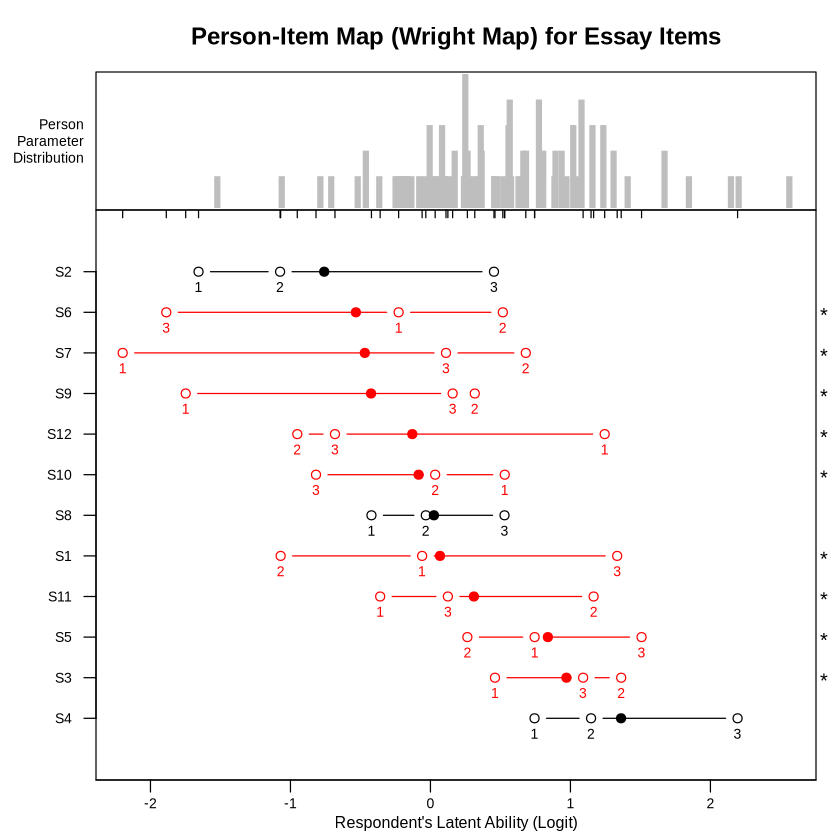

In [40]:
plotPImap(rasch_model_poli, 
          sorted = TRUE,
          main = "Person-Item Map (Wright Map) for Essay Items", 
          latdim = "Respondent's Latent Ability (Logit)", 
          warn.ord = TRUE,         
          warn.ord.col = "red")

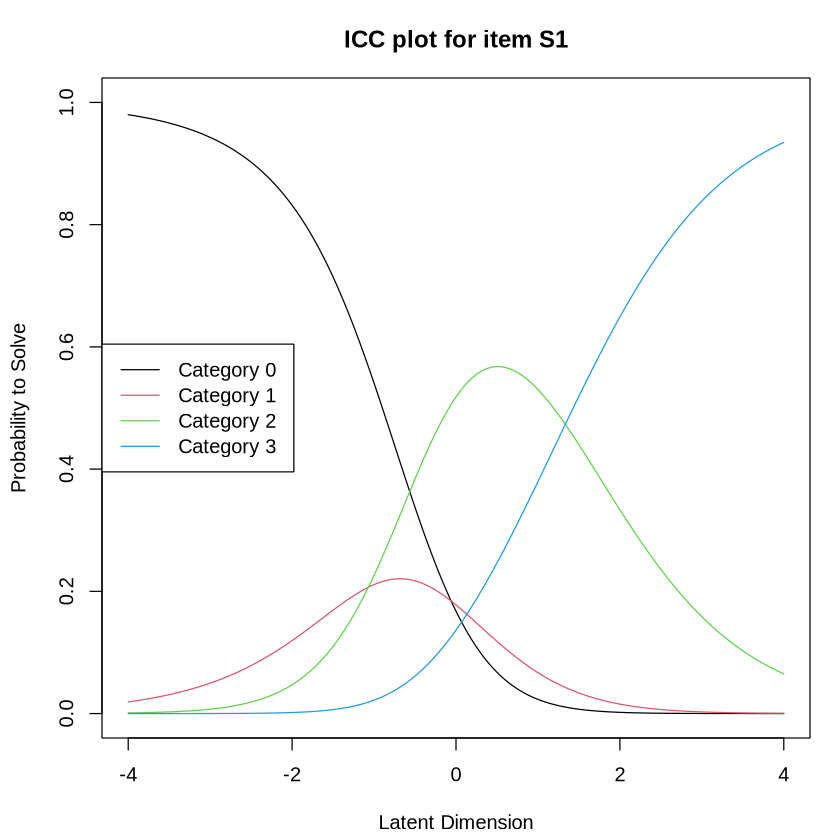

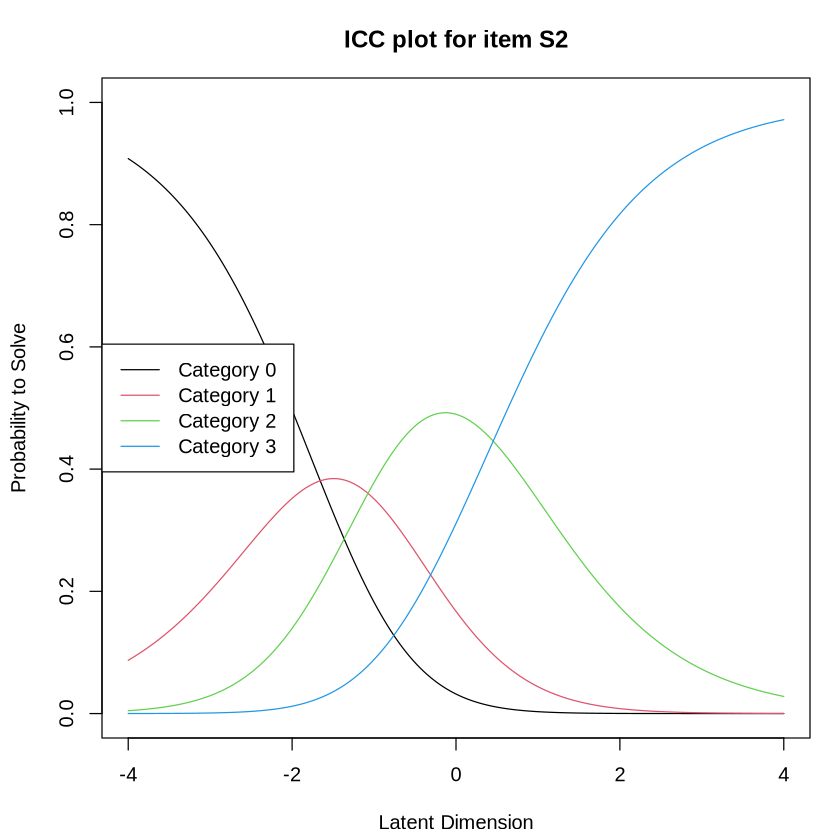

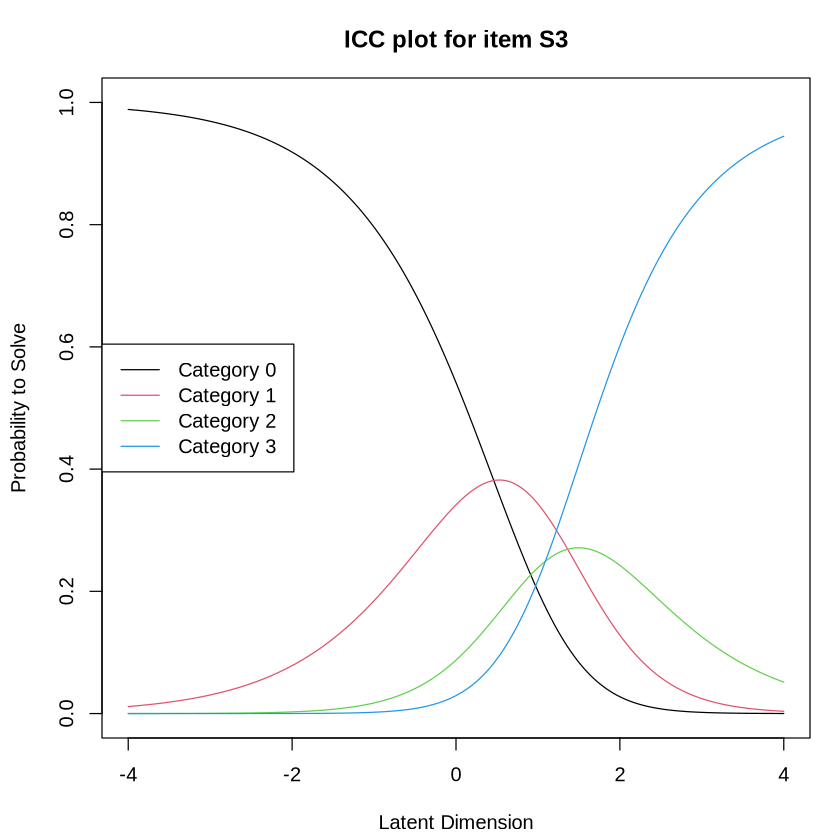

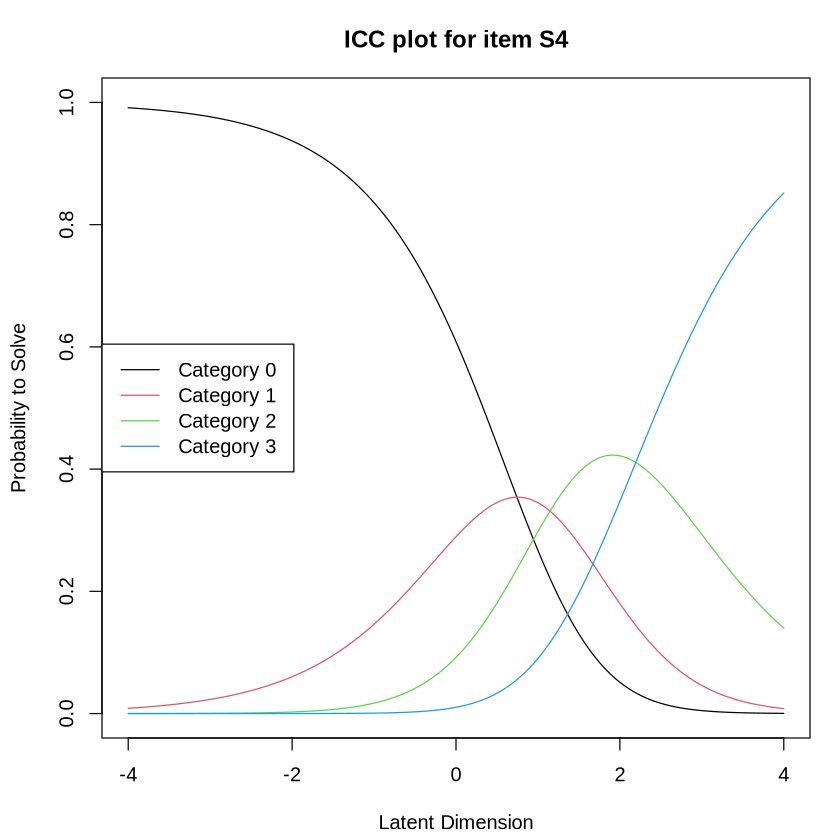

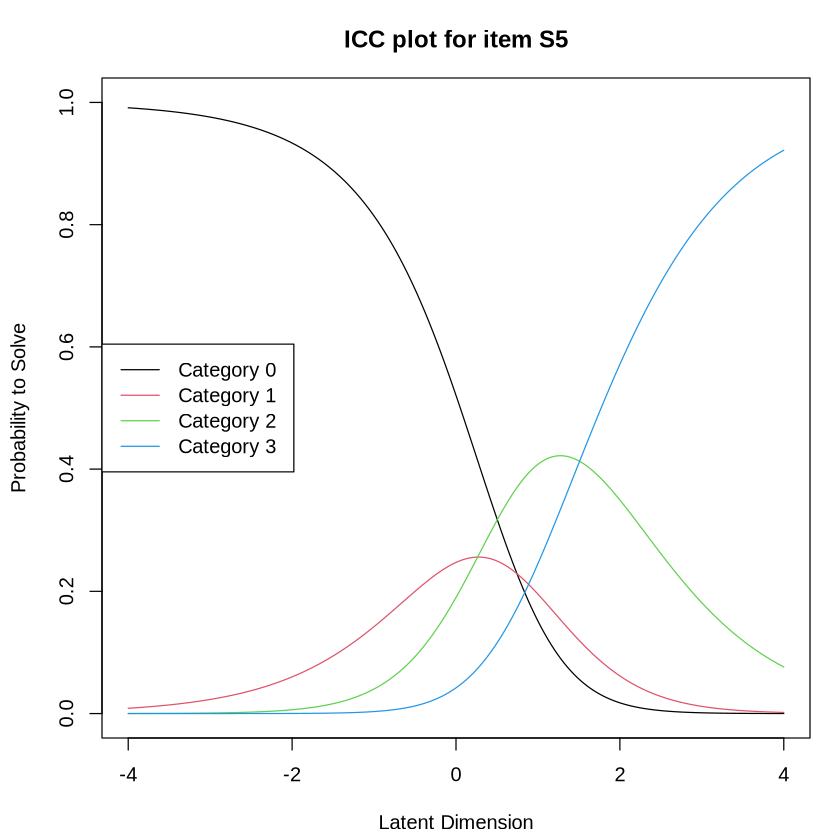

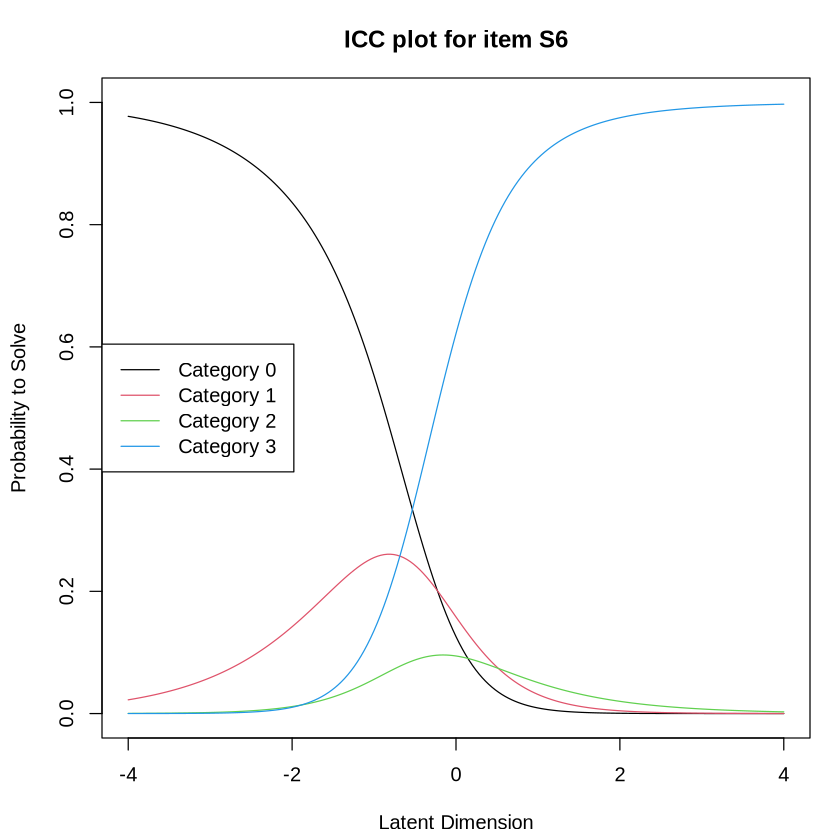

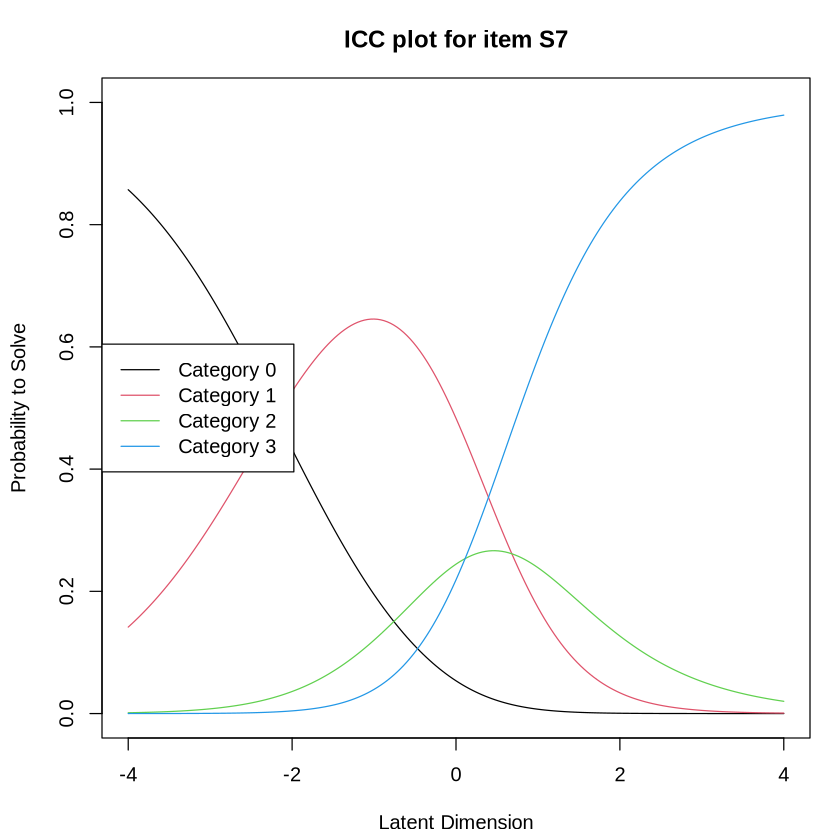

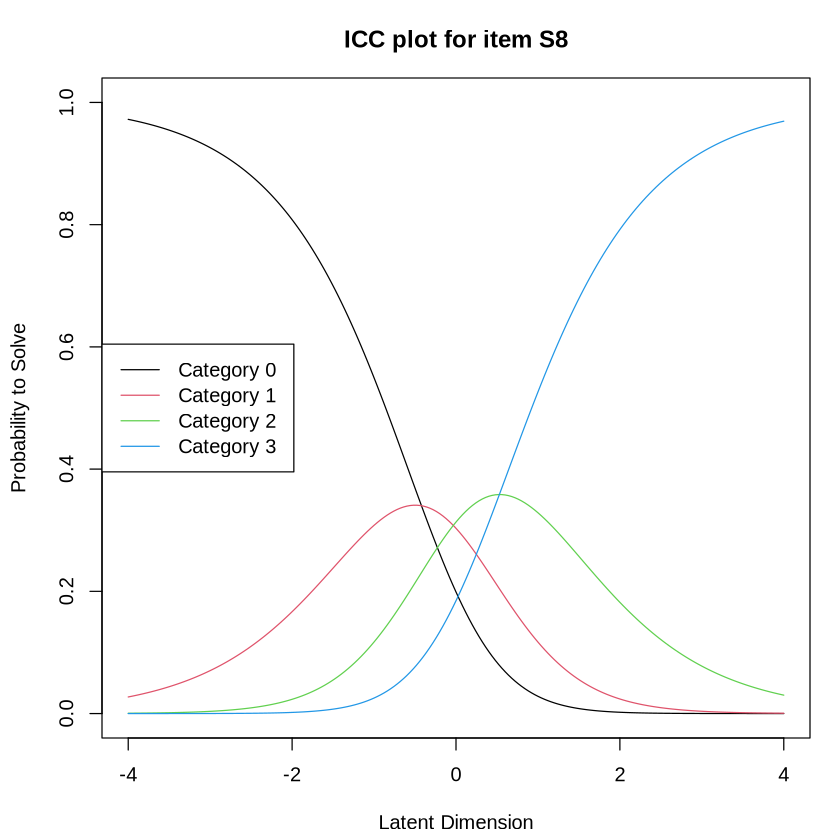

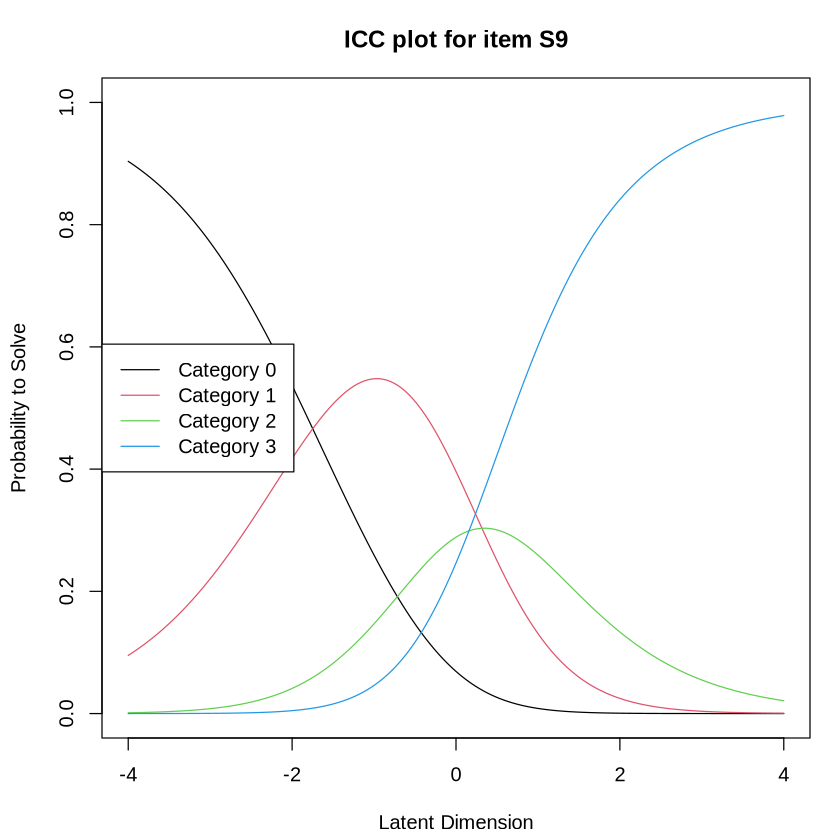

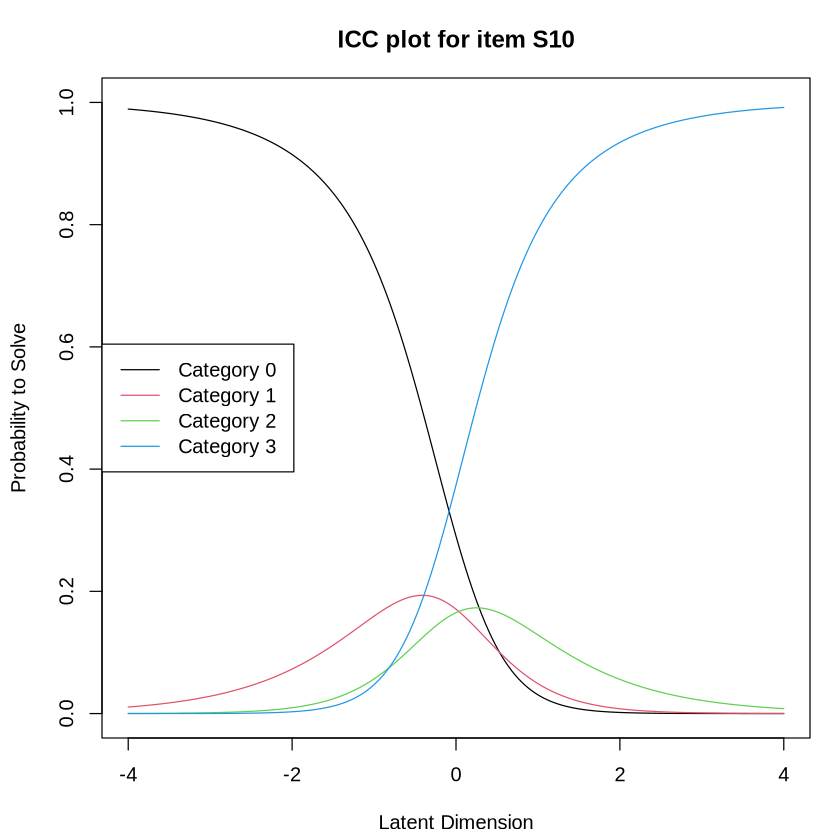

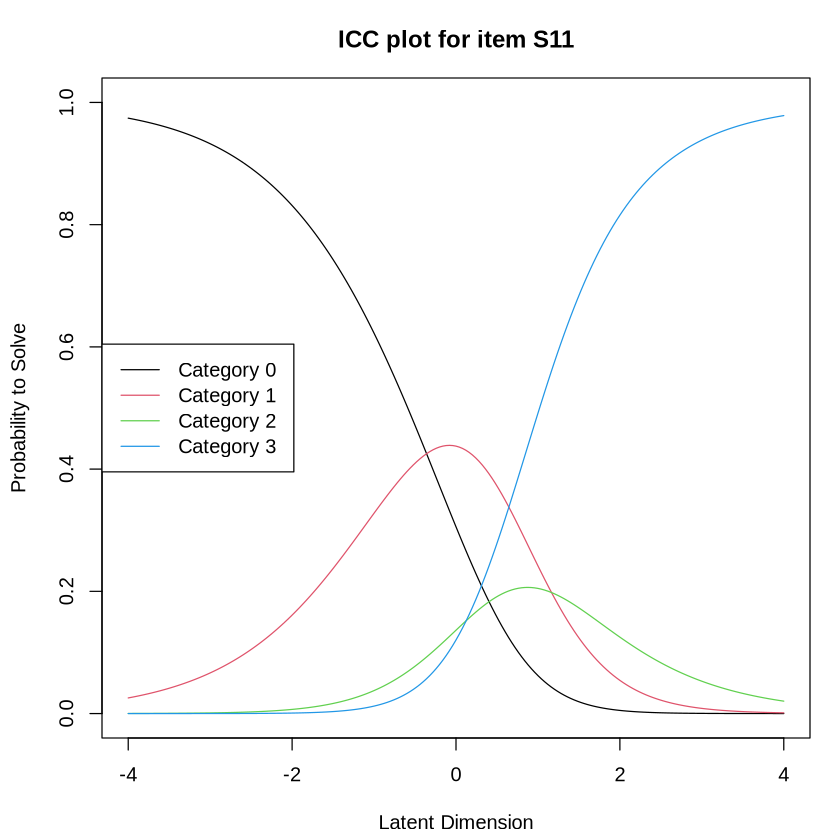

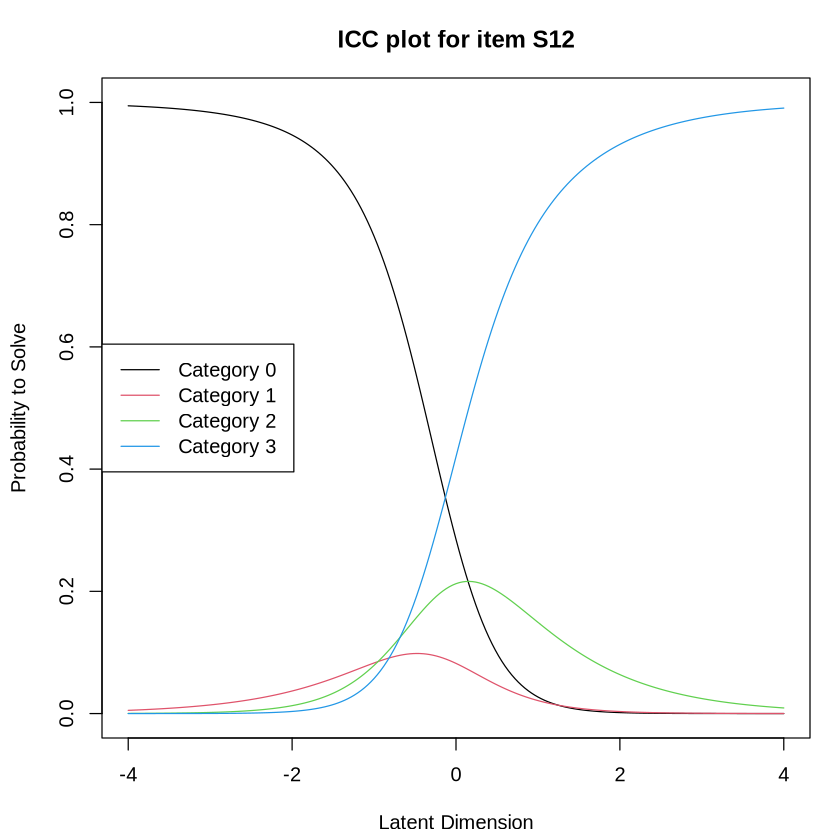

In [32]:
# Menampilkan grafik kurva untuk semua item
plotICC(rasch_model_poli)

# Jika hanya ingin melihat soal tertentu yang bermasalah (misal S2)
# plotICC(rasch_model_poli, itemSelect = "S2")

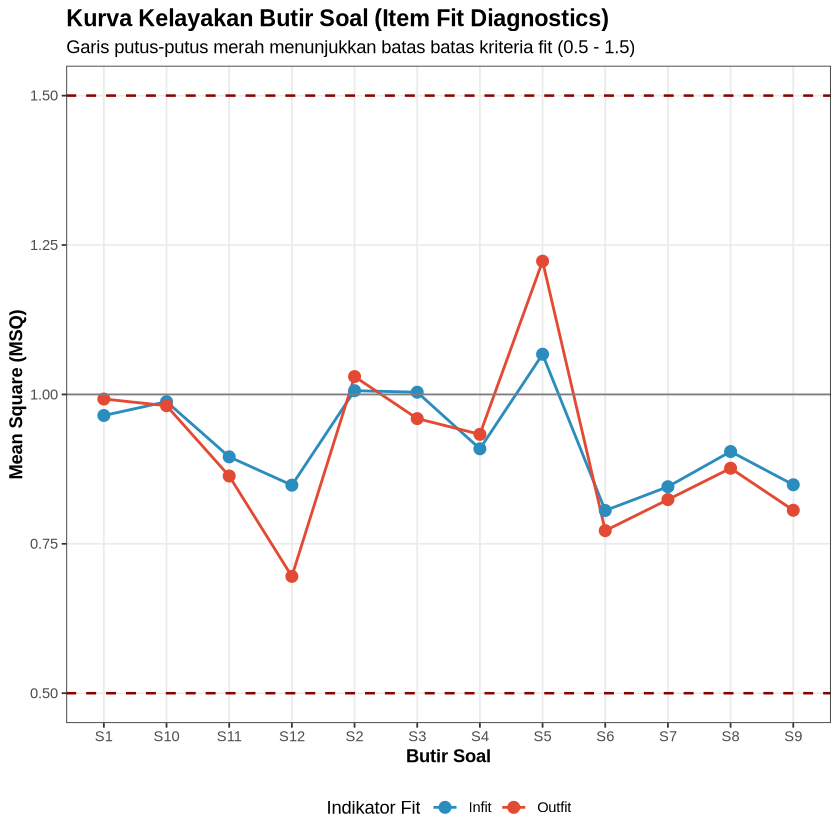

In [35]:
# 1. Pastikan library yang dibutuhkan sudah aktif
library(ggplot2)
library(dplyr)
library(tidyr)

# 2. Ekstrak nilai Infit dan Outfit MSQ dari objek fit_butir eRm
df_fit <- data.frame(
  Item = names(fit_butir$i.infitMSQ),
  Infit = fit_butir$i.infitMSQ,
  Outfit = fit_butir$i.outfitMSQ
)

# 3. Ubah format data menjadi 'long format' agar mudah di-plot oleh ggplot2
df_fit_long <- df_fit %>%
  pivot_longer(cols = c(Infit, Outfit), 
               names_to = "Fit_Type", 
               values_to = "MSQ")

# 4. Membuat plot dengan standar publikasi ilmiah
ggplot(df_fit_long, aes(x = Item, y = MSQ, color = Fit_Type, group = Fit_Type)) +
  geom_line(size = 0.8) +
  geom_point(size = 3) +
  # Menambahkan garis batas toleransi ideal untuk soal esai (politomus): 0.5 sampai 1.5
  geom_hline(yintercept = c(0.5, 1.5), linetype = "dashed", color = "darkred", linewidth = 0.7) +
  # Menambahkan garis tengah ideal (1.0)
  geom_hline(yintercept = 1.0, linetype = "solid", color = "gray50") +
  labs(
    title = "Kurva Kelayakan Butir Soal (Item Fit Diagnostics)",
    subtitle = "Garis putus-putus merah menunjukkan batas batas kriteria fit (0.5 - 1.5)",
    x = "Butir Soal",
    y = "Mean Square (MSQ)",
    color = "Indikator Fit"
  ) +
  scale_color_manual(values = c("Infit" = "#2b8cbe", "Outfit" = "#e34a33")) +
  theme_bw() + # Menggunakan tema black-white yang bersih untuk jurnal
  theme(
    plot.title = element_text(face = "bold", size = 14),
    axis.title = element_text(face = "bold"),
    panel.grid.minor = element_blank(),
    legend.position = "bottom"
  )

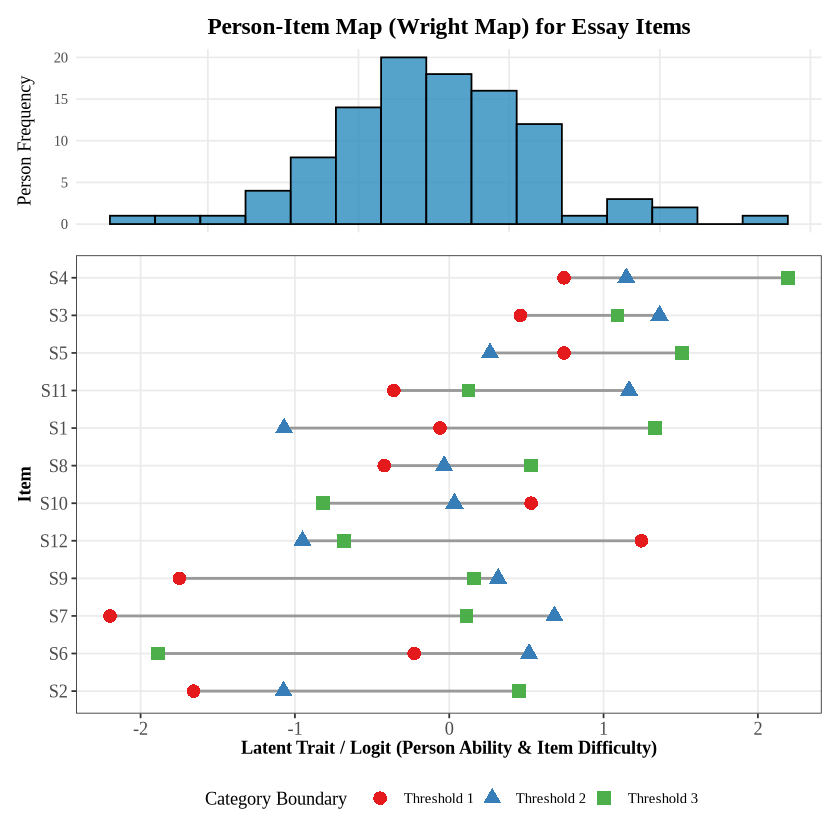

In [42]:
# 4. Ekstraksi Data Item (Ambang Batas / Thresholds) - DIPERBAIKI
thres_obj <- thresholds(rasch_model_poli)
df_item <- as.data.frame(thres_obj$threshtable[[1]])
df_item$Item <- rownames(df_item) 

# Mengubah data lebar menjadi panjang, fokus pada kolom 'Threshold' bukan 'Location'
df_item_long <- df_item %>%
  pivot_longer(cols = starts_with("Threshold"), # KUNCI PERBAIKAN 1: Ambil kolom Threshold
               names_to = "Category", 
               values_to = "Logit") %>%
  drop_na() 

# 5. Membangun Grafik Item (Bagian Bawah) - DIPERBAIKI
p_item <- ggplot(df_item_long, aes(x = Logit, y = reorder(Item, Logit, FUN = mean))) +
  # KUNCI PERBAIKAN 2: Menambahkan group = Item agar garis ditarik per soal
  geom_line(aes(group = Item), color = "gray60", size = 0.8) + 
  geom_point(aes(color = Category, shape = Category), size = 3.5) + 
  theme_bw(base_family = "serif") +
  labs(x = "Latent Trait / Logit (Person Ability & Item Difficulty)", 
       y = "Item", 
       color = "Category Boundary", 
       shape = "Category Boundary") +
  scale_color_brewer(palette = "Set1") + 
  theme(legend.position = "bottom",
        panel.grid.minor = element_blank(),
        axis.title = element_text(face = "bold"),
        axis.text = element_text(size = 11))

# 6. Menggabungkan Kembali dengan Patchwork
wright_map_final <- p_person / p_item + plot_layout(heights = c(1, 2.5))
print(wright_map_final)

In [44]:
# Menghitung Reliabilitas Separasi berdasarkan person parameter
reliabilitas <- SepRel(person_param)

# Menampilkan hasil
summary(reliabilitas)

       Separation Reliability: 0.6999

            Observed Variance: 0.4437 (Squared Standard Deviation)
Mean Square Measurement Error: 0.1332 (Model Error Variance)


In [48]:
# 1. Membuat dataset baru yang hanya berisi responden dengan jawaban utuh
data_lengkap <- na.omit(data_clean)

# 2. Mengecek berapa sisa responden kita
cat("Jumlah responden awal: ", nrow(data_lengkap), "\n")
cat("Jumlah responden setelah NA dibuang: ", nrow(data_lengkap), "\n")

# 3. Menjalankan ulang model PCM KHUSUS untuk data utuh
rasch_model_lengkap <- PCM(data_lengkap)

# 4. Melakukan uji Martin-Löf pada data yang sudah utuh
uji_unidimensi <- MLoef(rasch_model_lengkap, splitcr = "median")
print(uji_unidimensi)

Jumlah responden awal:  40 
Jumlah responden setelah NA dibuang:  40 


Warning message:
“
The following items have no 0-responses:
S7
Responses are shifted such that lowest category is 0.”



Martin-Loef-Test (split criterion: median)
LR-value: 71.502 
Chi-square df: 305 
p-value: 1 

